In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [ ]:
data=pd.read_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_cleaned.csv')

In [ ]:
data.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.66,0.0,0.0,0.0,0.02,26.88,71.16,0.0
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.65,0.0,0.0,0.0,0.02,26.88,71.16,0.0
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.67,0.0,...,0.02,27.69,65.63,0.0,0.0,0.0,0.02,26.88,71.18,0.0
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,0.00,0.00,0.0,0.0,0.0,0.02,26.88,71.19,0.0
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,0.00,0.00,0.0,0.0,0.0,0.02,26.88,71.21,0.0


In [ ]:
data.drop('Date',axis='columns',inplace=True)

<Axes: >

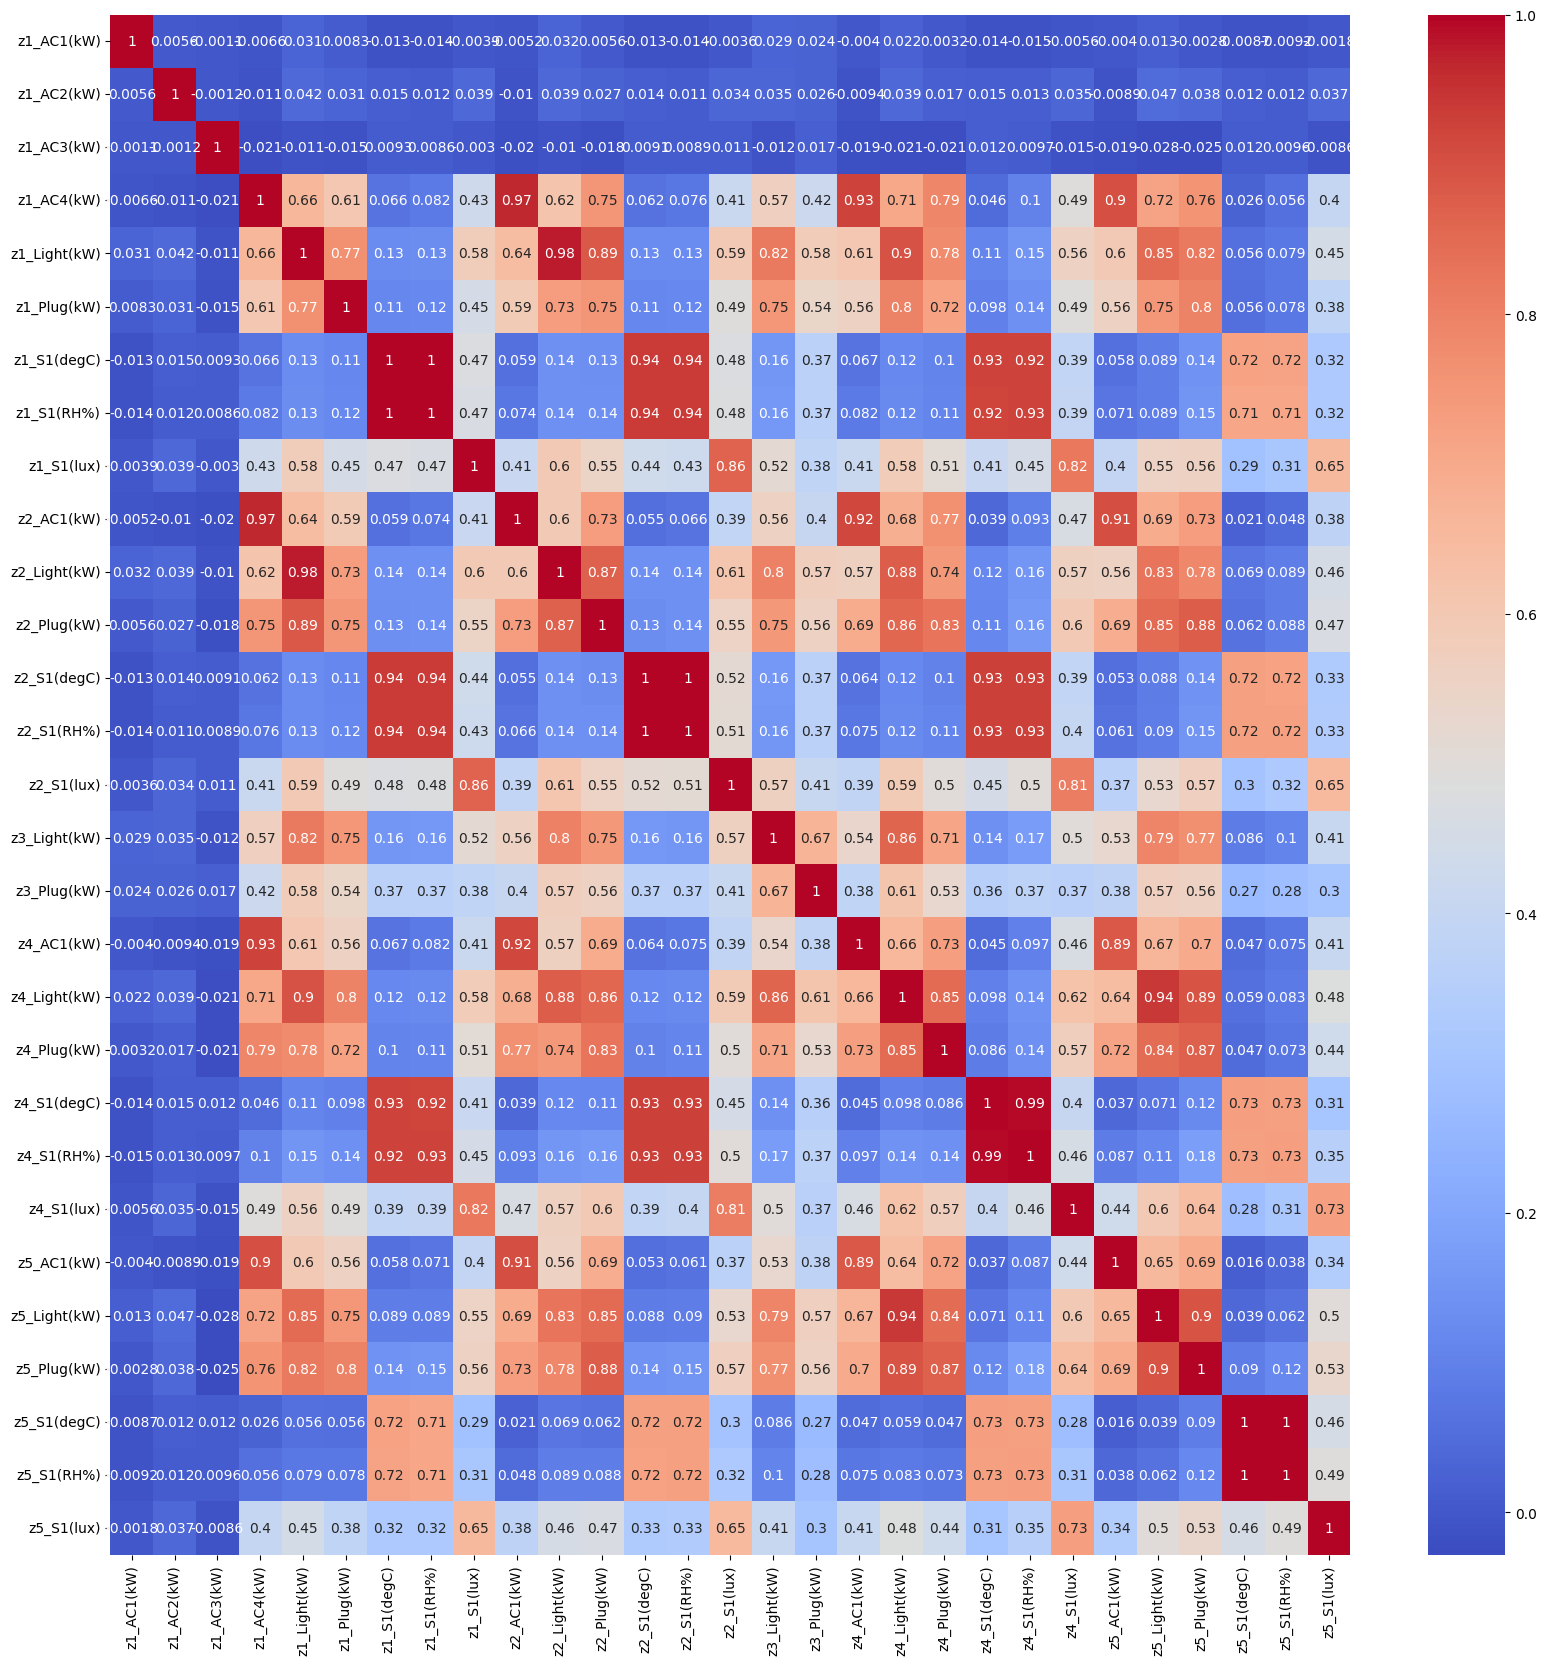

In [ ]:
plt.figure(figsize=(20,20))
corrs=data.corr()
sns.heatmap(corrs,annot=True,cmap='coolwarm')

In [ ]:
def highly_correlated_features(data, threshold=0.95):

  corr_matrix = data.corr().abs()
  upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
  highly_correlated_pairs = []
  for column in upper.columns:
    for row in upper.index:
      if upper.loc[row, column] > threshold:
        highly_correlated_pairs.append(((row, column), upper.loc[row, column]))
  return highly_correlated_pairs

In [ ]:
highly_correlated_features(data)

[(('z1_S1(degC)', 'z1_S1(RH%)'), 0.9974082069498837),
 (('z1_AC4(kW)', 'z2_AC1(kW)'), 0.9673451119745493),
 (('z1_Light(kW)', 'z2_Light(kW)'), 0.9781610193293118),
 (('z2_S1(degC)', 'z2_S1(RH%)'), 0.9970429111904534),
 (('z4_S1(degC)', 'z4_S1(RH%)'), 0.9936775931214379),
 (('z5_S1(degC)', 'z5_S1(RH%)'), 0.9962519542852675)]

In [ ]:
high_corrs=highly_correlated_features(data)
columns_to_drop=[]
for i in high_corrs:
  columns_to_drop.append(i[0][0])
columns_to_drop

['z1_S1(degC)',
 'z1_AC4(kW)',
 'z1_Light(kW)',
 'z2_S1(degC)',
 'z4_S1(degC)',
 'z5_S1(degC)']

In [ ]:
data.drop(columns_to_drop,axis='columns',inplace=True)

In [ ]:
#Function to get the constant or nearly constant features
def constant_columns(df,thershold=0.0002):
  constant_columns = []
  for column in df.columns:
    unique_count=df[column].nunique()
    unique_ratio=unique_count/len(df)
    if unique_ratio<thershold:
      constant_columns.append(column)
  return constant_columns

In [ ]:
columns_to_drop=constant_columns(data)
columns_to_drop

['z1_AC1(kW)', 'z5_S1(lux)']

In [ ]:
# Drop columns that they're almost constant
columns_to_drop=constant_columns(data)
data.drop(columns_to_drop,axis='columns',inplace=True)

<Axes: >

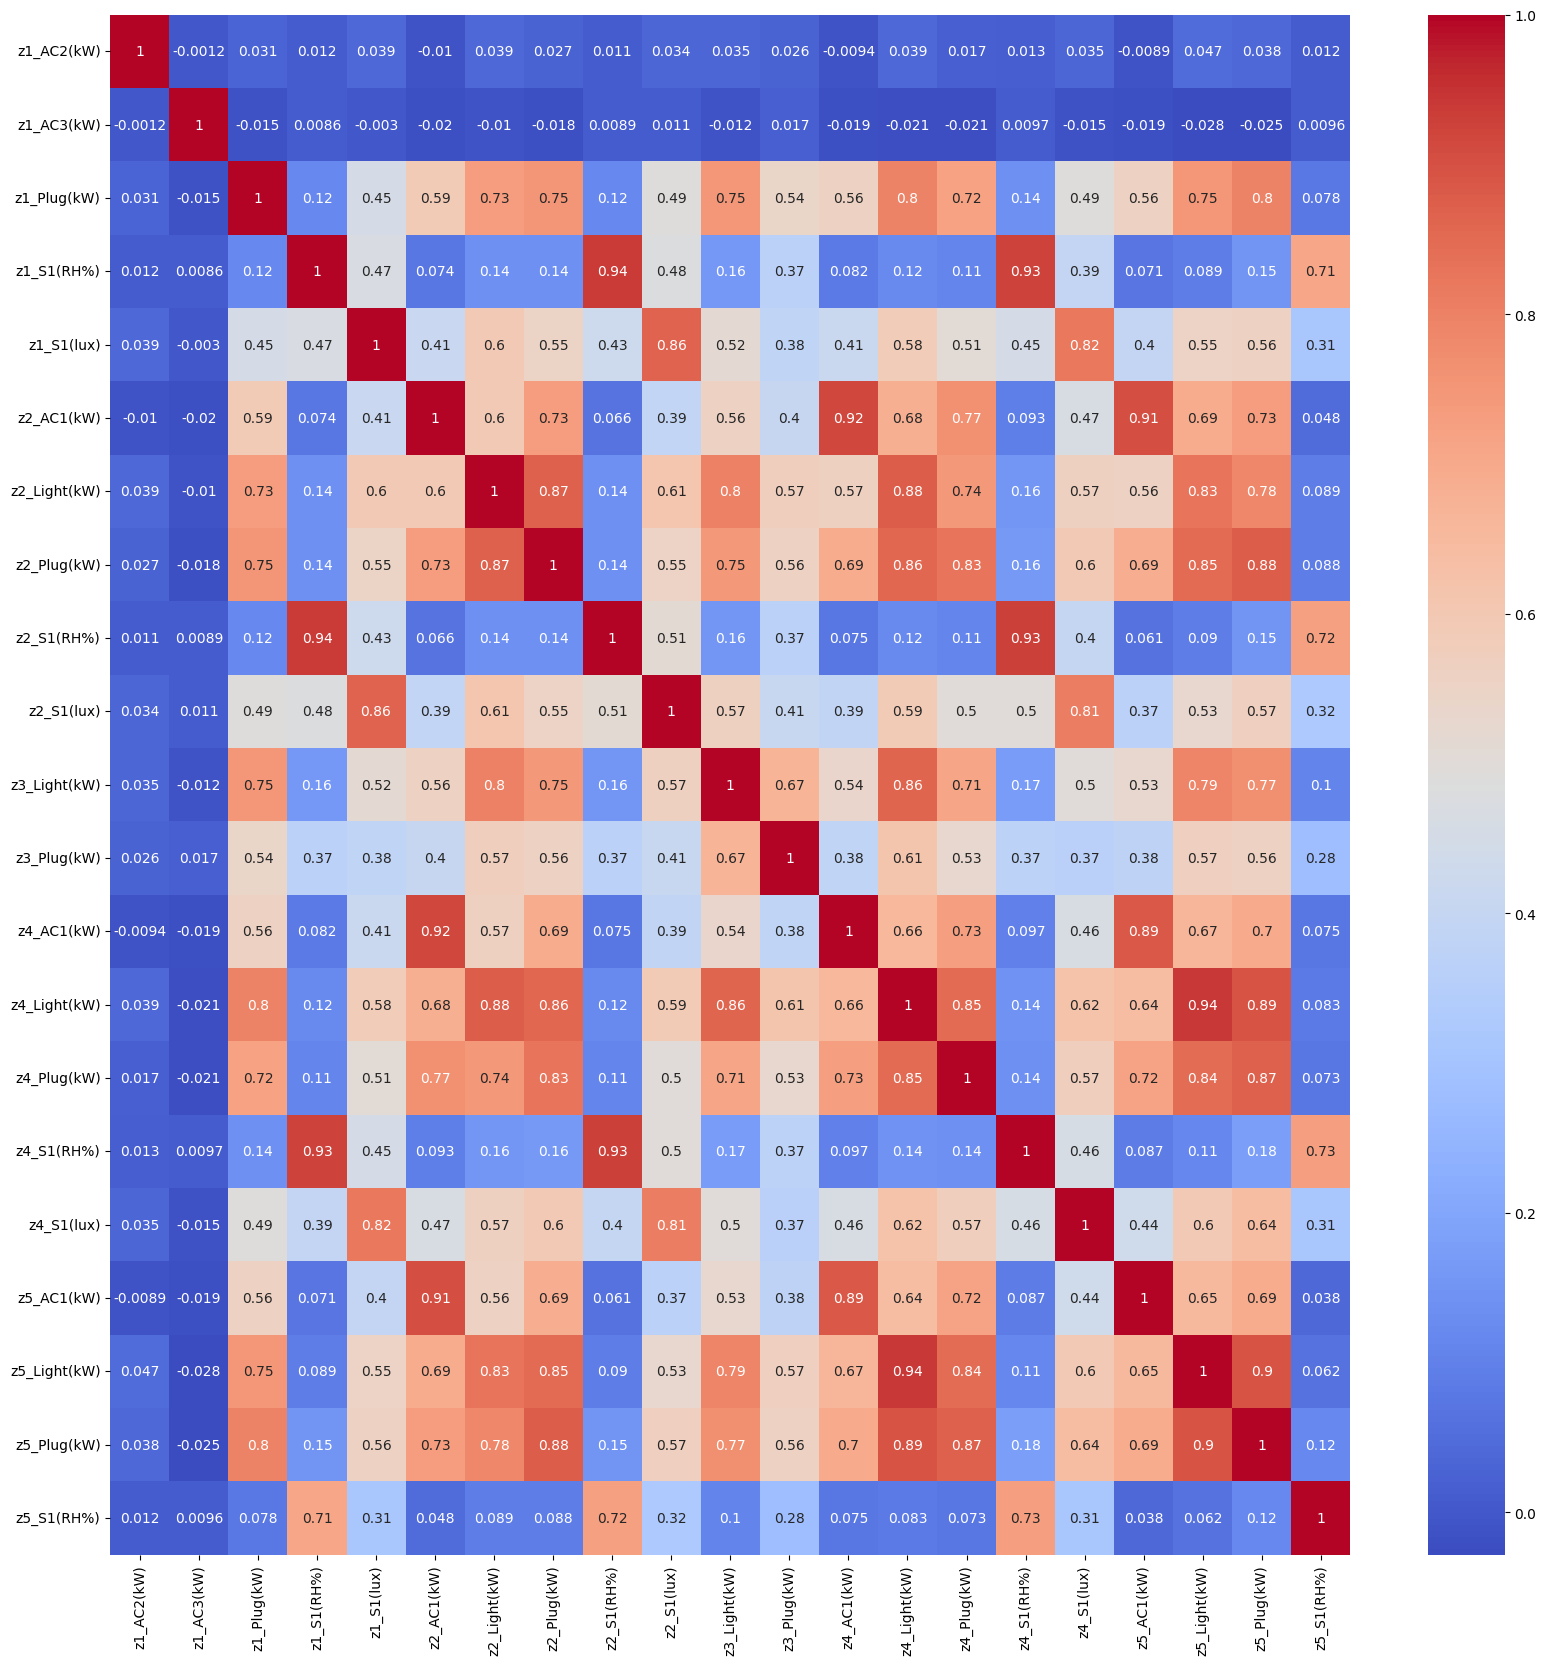

In [ ]:
plt.figure(figsize=(20,20))
corrs=data.corr()
sns.heatmap(corrs,annot=True,cmap='coolwarm')

In [ ]:
data.to_csv('drive/MyDrive/Intent-Based Energy Reduction/Data/Floor3_features_selected.csv',index=False)